# Chatbot with Memory — LangGraph

**Graph:** START → chat_node → END (loops via caller code)

**Concepts covered:**
1. `add_messages` — built-in reducer for conversation history
2. `BaseMessage` hierarchy (`HumanMessage`, `AIMessage`)
3. `MemorySaver` checkpointer — RAM-based persistence
4. `thread_id` — identifies which conversation session to resume

> **Note on `input()`:** Jupyter's `input()` has UI quirks; cells below use `simulate_chat()` with a predefined list to replicate the while-loop logic without blocking `nbconvert`.

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from typing import TypedDict, Annotated, List
from dotenv import load_dotenv

load_dotenv()

True

## Step 1 — Define State

`add_messages` is LangGraph's built-in reducer for message lists.
It appends new messages instead of replacing the whole list — optimised for `BaseMessage` objects.

```
operator.add  →  generic list append (works for any type)
add_messages  →  same behaviour, but smarter with BaseMessage (deduplicates by id, etc.)
```

In [2]:
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

## Step 2 — Mock LLM

No real API key available, so `MockChatModel` simulates an LLM that returns `AIMessage` objects.

In [3]:
class MockChatModel:
    """Returns predefined AIMessage responses in order, cycling at the end."""
    def __init__(self, responses: list):
        self._responses = responses
        self._idx = 0

    def invoke(self, messages):
        text = self._responses[self._idx % len(self._responses)]
        self._idx += 1
        return AIMessage(content=text)

    def reset(self):
        self._idx = 0

## Step 3 — chat_node

Single node: reads all messages from state → calls LLM → returns new AI message as a list (so `add_messages` appends it).

In [4]:
def make_chat_node(llm):
    """Factory so different LLM mocks can share the same node logic."""
    def chat_node(state: ChatState) -> dict:
        messages = state['messages']
        response = llm.invoke(messages)
        return {'messages': [response]}
    return chat_node

---
## Part A — Chatbot WITHOUT Persistence (demonstrates the memory problem)

In [5]:
broken_llm = MockChatModel([
    'Hello Nitesh! How can I assist you?',
    "I'm sorry, I don't have access to your personal information.",
])

graph_a = StateGraph(ChatState)
graph_a.add_node('chat_node', make_chat_node(broken_llm))
graph_a.add_edge(START, 'chat_node')
graph_a.add_edge('chat_node', END)

chatbot_no_mem = graph_a.compile()
print('Graph A compiled (no persistence).')

Graph A compiled (no persistence).


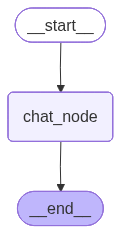

In [6]:
from IPython.display import Image, display
display(Image(chatbot_no_mem.get_graph().draw_mermaid_png()))

### Invoke 1 — introduce ourselves

In [7]:
out1 = chatbot_no_mem.invoke({'messages': [HumanMessage(content='Hi, my name is Nitesh.')]})
print('You :', 'Hi, my name is Nitesh.')
print('AI  :', out1['messages'][-1].content)

You : Hi, my name is Nitesh.
AI  : Hello Nitesh! How can I assist you?


### Invoke 2 — test memory (fresh invoke = fresh state, no history)

In [8]:
out2 = chatbot_no_mem.invoke({'messages': [HumanMessage(content='What is my name?')]})
print('You :', 'What is my name?')
print('AI  :', out2['messages'][-1].content)
print()
print('Problem: each invoke() starts with a fresh state.')
print('The LLM only sees the single new message — past conversation is gone.')

You : What is my name?
AI  : I'm sorry, I don't have access to your personal information.

Problem: each invoke() starts with a fresh state.
The LLM only sees the single new message — past conversation is gone.


---
## Part B — Chatbot WITH MemorySaver (persistence)

**What changes:**
1. Create a `MemorySaver` checkpointer (stores state in RAM)
2. Pass it to `graph.compile(checkpointer=...)`
3. Every `invoke()` now also passes `config={'configurable': {'thread_id': ...}}`

LangGraph then:
- Before execution: loads previous state for that thread from RAM
- After execution: saves updated state back to RAM

Result: conversation history accumulates across multiple `invoke()` calls.

In [9]:
memory_llm = MockChatModel([
    'Hello Nitesh! Nice to meet you.',
    'Your name is Nitesh! How can I assist you today?',
    'Sure! 10 + 100 = 110.',
    'Sure! 110 × 2 = 220.',
    'Goodbye! It was great chatting with you.',
])

checkpointer = MemorySaver()

graph_b = StateGraph(ChatState)
graph_b.add_node('chat_node', make_chat_node(memory_llm))
graph_b.add_edge(START, 'chat_node')
graph_b.add_edge('chat_node', END)

chatbot = graph_b.compile(checkpointer=checkpointer)
print('Graph B compiled (with MemorySaver).')

Graph B compiled (with MemorySaver).


In [10]:
# thread_id identifies one user's conversation session
thread_id = 'user_nitesh_001'
config = {'configurable': {'thread_id': thread_id}}

### Multi-turn conversation — memory works across invoke() calls

In [11]:
exchanges = [
    'Hi, my name is Nitesh.',
    'What is my name?',
    'Can you add 10 to 100?',
    'Now can you multiply the result with 2?',
]

for user_msg in exchanges:
    response = chatbot.invoke(
        {'messages': [HumanMessage(content=user_msg)]},
        config=config
    )
    ai_reply = response['messages'][-1].content
    print(f'You : {user_msg}')
    print(f'AI  : {ai_reply}')
    print()

You : Hi, my name is Nitesh.
AI  : Hello Nitesh! Nice to meet you.

You : What is my name?
AI  : Your name is Nitesh! How can I assist you today?

You : Can you add 10 to 100?
AI  : Sure! 10 + 100 = 110.

You : Now can you multiply the result with 2?
AI  : Sure! 110 × 2 = 220.



### Inspect full conversation state stored in RAM

In [12]:
state_snapshot = chatbot.get_state(config)
print(f'Total messages stored: {len(state_snapshot.values["messages"])}')
print()
for i, msg in enumerate(state_snapshot.values['messages']):
    role = 'You' if isinstance(msg, HumanMessage) else 'AI '
    print(f'[{i+1}] {role}: {msg.content}')

Total messages stored: 8

[1] You: Hi, my name is Nitesh.
[2] AI : Hello Nitesh! Nice to meet you.
[3] You: What is my name?
[4] AI : Your name is Nitesh! How can I assist you today?
[5] You: Can you add 10 to 100?
[6] AI : Sure! 10 + 100 = 110.
[7] You: Now can you multiply the result with 2?
[8] AI : Sure! 110 × 2 = 220.


---
## Part C — Interactive while-loop pattern

The instructor's code uses `input()` inside a `while True` loop. Shown below as `simulate_chat()` with a predefined list (identical logic — swap `predefined_messages` with `input()` to run interactively in a terminal).

In [13]:
# Reset mock LLM so responses start fresh
memory_llm.reset()

# Fresh checkpointer + thread for this demo
loop_checkpointer = MemorySaver()
graph_c = StateGraph(ChatState)
graph_c.add_node('chat_node', make_chat_node(memory_llm))
graph_c.add_edge(START, 'chat_node')
graph_c.add_edge('chat_node', END)
loop_chatbot = graph_c.compile(checkpointer=loop_checkpointer)

loop_thread = {'configurable': {'thread_id': 'loop_demo'}}


def simulate_chat(chatbot_instance, config, predefined_messages):
    """Mimics the while-loop chatbot. Replace list with input() for real terminal use."""
    print('=== Chat started (type exit / quit / bye to stop) ===')
    for user_msg in predefined_messages:
        # --- same logic as: user_msg = input('You: ') ---
        if user_msg.strip().lower() in ('exit', 'quit', 'bye'):
            print('Chat ended.')
            break
        print(f'You : {user_msg}')
        response = chatbot_instance.invoke(
            {'messages': [HumanMessage(content=user_msg)]},
            config=config
        )
        print(f'AI  : {response["messages"][-1].content}')
        print()


simulate_chat(
    loop_chatbot,
    loop_thread,
    [
        'Hi, my name is Nitesh.',
        'What is my name?',
        'Can you add 10 to 100?',
        'Now can you multiply the result with 2?',
        'bye',
    ]
)

=== Chat started (type exit / quit / bye to stop) ===
You : Hi, my name is Nitesh.
AI  : Hello Nitesh! Nice to meet you.

You : What is my name?
AI  : Your name is Nitesh! How can I assist you today?

You : Can you add 10 to 100?
AI  : Sure! 10 + 100 = 110.

You : Now can you multiply the result with 2?
AI  : Sure! 110 × 2 = 220.

Chat ended.


---
## Summary

| Feature | Without MemorySaver | With MemorySaver |
|---|---|---|
| State between `invoke()` calls | Lost (fresh each time) | Persisted in RAM |
| Second invoke knows name | No | Yes |
| Config needed | No | Yes — `{'configurable': {'thread_id': ...}}` |
| Works after program restart | — | No (RAM-only) |
| Production use | — | Use DB-backed checkpointer (SqliteSaver, PostgresSaver) |